# AlphaGenome Variant Analysis (cohort)

This notebook analyzes AlphaGenome variant scoring results and generates visualizations and summary tables.

## Setup
1. Set the `INPUT_DIR` variable to point to your directory containing AlphaGenome CSV files
2. Set the `OUTPUT_DIR` variable for saving results
3. Run all cells in order

## 1. Configuration

In [13]:
# ============================================
# CONFIGURATION
# ============================================

# Current cohort output directory from 01_alphagenome_analysis notebook.
INPUT_DIR = "../01_alphagenome_analysis/alphagenome_intron6_cohort/csv/"   # Directory containing alphagenome_scores_*.csv files
OUTPUT_DIR = "./plots_patients_cohort"  # Directory for output files

# Pathogenicity thresholds (customized)
THRESHOLD_HIGH = 0.999      # Top 0.1%
THRESHOLD_MODERATE = 0.99   # Top 1%
THRESHOLD_LOW = 0.95        # Top 5%

## 2. Import Libraries

In [14]:
import glob
import os
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from plotnine import *

warnings.filterwarnings('ignore')

# Create output directory if needed
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Input directory: {INPUT_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Input directory: ../01_alphagenome_analysis/alphagenome_intron6_cohort/csv/
Output directory: ./plots_patients_cohort


## 3. Data Loading Function

In [15]:
def load_alphagenome_files(input_dir: str) -> pd.DataFrame:
    """
    Load all AlphaGenome CSV files from a directory and combine them.
    
    Parameters
    ----------
    input_dir : str
        Path to directory containing AlphaGenome CSV files
        
    Returns
    -------
    pd.DataFrame
        Combined dataframe with all variant scores
    """
    file_pattern = os.path.join(input_dir, 'alphagenome_scores_*.csv')
    files = glob.glob(file_pattern)

    # Backward-compatible fallback: old folder name -> current folder name.
    if not files and 'alphagenome_patients_cohort' in input_dir:
        fallback_dir = input_dir.replace('alphagenome_patients_cohort', 'alphagenome_intron6_cohort')
        fallback_pattern = os.path.join(fallback_dir, 'alphagenome_scores_*.csv')
        fallback_files = glob.glob(fallback_pattern)
        if fallback_files:
            print(f"No files in {input_dir}. Using fallback: {fallback_dir}")
            input_dir = fallback_dir
            files = fallback_files

    if not files:
        raise FileNotFoundError(f"No AlphaGenome CSV files found in {input_dir}")
    
    print(f"Found {len(files)} AlphaGenome score files:")
    for f in sorted(files):
        print(f"  - {os.path.basename(f)}")
    
    # Load and combine all files
    dfs = []
    for f in files:
        df = pd.read_csv(f)
        dfs.append(df)
    
    combined_df = pd.concat(dfs, ignore_index=True)
    
    # Clean up - remove unnamed index column if present
    if 'Unnamed: 0' in combined_df.columns:
        combined_df = combined_df.drop(columns=['Unnamed: 0'])
    
    # Data quality checks
    print(f"\n--- Data Quality Check ---")
    print(f"Total rows: {combined_df.shape[0]}")
    print(f"Total columns: {combined_df.shape[1]}")
    
    # Check for duplicate columns
    dup_cols = combined_df.columns[combined_df.columns.duplicated()].tolist()
    if dup_cols:
        print(f"WARNING: Duplicate columns found: {dup_cols}")
        combined_df = combined_df.loc[:, ~combined_df.columns.duplicated()]
    else:
        print("✓ No duplicate columns")
    
    return combined_df

## 4. Pathogenicity Classification Function

In [16]:
def classify_pathogenicity(quantile: float, 
                           threshold_high: float = 0.999,
                           threshold_moderate: float = 0.99,
                           threshold_low: float = 0.95) -> str:
    """
    Classify variant pathogenicity based on quantile score.
    
    Parameters
    ----------
    quantile : float
        AlphaGenome quantile score (0-1)
    threshold_high : float
        Threshold for High Impact classification
    threshold_moderate : float
        Threshold for Moderate Impact classification
    threshold_low : float
        Threshold for Low Impact classification
        
    Returns
    -------
    str
        Impact classification
    """
    if quantile >= threshold_high:
        return 'High Impact'
    elif quantile >= threshold_moderate:
        return 'Moderate Impact'
    elif quantile >= threshold_low:
        return 'Low Impact'
    else:
        return 'Likely Benign'

## 5. Variant Summary Function

In [17]:
def create_variant_summary(combined_df: pd.DataFrame,
                           threshold_high: float = 0.999,
                           threshold_moderate: float = 0.99,
                           threshold_low: float = 0.95) -> pd.DataFrame:
    """
    Create summary statistics for each variant.
    
    Parameters
    ----------
    combined_df : pd.DataFrame
        Combined AlphaGenome scores dataframe
    threshold_high, threshold_moderate, threshold_low : float
        Classification thresholds
        
    Returns
    -------
    pd.DataFrame
        Summary dataframe with one row per variant
    """
    variant_summary = []
    
    for variant in combined_df['variant_id'].unique():
        var_data = combined_df[combined_df['variant_id'] == variant]
        
        # Extract position and change from variant_id
        parts = variant.split(':')
        position = int(parts[1])
        change = parts[2]
        
        # Get scores by output type
        splice_junction_data = var_data[var_data['output_type'] == 'SPLICE_JUNCTIONS']
        splice_site_data = var_data[var_data['output_type'] == 'SPLICE_SITE_USAGE']
        
        summary = {
            'variant_id': variant,
            'position': position,
            'change': change,
            'n_predictions': len(var_data),
            # Splice junction scores
            'splice_junction_max_raw': splice_junction_data['raw_score'].max() if len(splice_junction_data) > 0 else np.nan,
            'splice_junction_max_quantile': splice_junction_data['quantile_score'].max() if len(splice_junction_data) > 0 else np.nan,
            'splice_junction_mean_raw': splice_junction_data['raw_score'].mean() if len(splice_junction_data) > 0 else np.nan,
            'splice_junction_mean_quantile': splice_junction_data['quantile_score'].mean() if len(splice_junction_data) > 0 else np.nan,
            # Splice site usage scores
            'splice_site_max_raw': splice_site_data['raw_score'].max() if len(splice_site_data) > 0 else np.nan,
            'splice_site_max_quantile': splice_site_data['quantile_score'].max() if len(splice_site_data) > 0 else np.nan,
            'splice_site_mean_raw': splice_site_data['raw_score'].mean() if len(splice_site_data) > 0 else np.nan,
            'splice_site_mean_quantile': splice_site_data['quantile_score'].mean() if len(splice_site_data) > 0 else np.nan,
        }
        
        # Overall max scores
        summary['overall_max_raw'] = var_data['raw_score'].max()
        summary['overall_max_quantile'] = var_data['quantile_score'].max()
        summary['overall_mean_quantile'] = var_data['quantile_score'].mean()
        
        variant_summary.append(summary)
    
    summary_df = pd.DataFrame(variant_summary)
    summary_df = summary_df.sort_values('overall_max_quantile', ascending=False)
    
    # Add classifications
    summary_df['short_variant'] = summary_df['variant_id'].apply(
        lambda x: x.split(':')[1] + ':' + x.split(':')[2]
    )
    summary_df['impact_class'] = summary_df['overall_max_quantile'].apply(
        lambda x: classify_pathogenicity(x, threshold_high, threshold_moderate, threshold_low)
    )
    
    return summary_df

## 6. Visualization Functions

### 6.2 Scores Heatmap

In [18]:
def plot_scores_heatmap(combined_df: pd.DataFrame, summary_df: pd.DataFrame, output_dir: str = None):
    """
    Create heatmap of scores by variant and output type.
    
    Parameters
    ----------
    combined_df : pd.DataFrame
        Combined AlphaGenome scores dataframe
    summary_df : pd.DataFrame
        Variant summary dataframe
    output_dir : str, optional
        Output directory for saving plots
    """
    # Get max quantile score for each variant and output type
    heatmap_data = combined_df.groupby(['variant_id', 'output_type'])['quantile_score'].max().reset_index()
    heatmap_data['short_variant'] = heatmap_data['variant_id'].apply(
        lambda x: x.split(':')[1] + ':' + x.split(':')[2]
    )
    
    # Pivot for heatmap
    heatmap_pivot = heatmap_data.pivot(index='short_variant', columns='output_type', values='quantile_score')
    
    # Sort by overall impact
    order = summary_df.sort_values('overall_max_quantile', ascending=False)['short_variant'].tolist()
    heatmap_pivot = heatmap_pivot.reindex(order)
    
    fig, ax = plt.subplots(figsize=(6, 6))
    
    sns.heatmap(
        heatmap_pivot,
        annot=True,
        fmt='.4f',
        cmap='RdYlGn_r',
        vmin=0.9,
        vmax=1.0,
        linewidths=0.5,
        cbar_kws={'label': 'Quantile Score'},
        ax=ax
    )
    
    ax.set_title('AlphaGenome scores by variant and prediction type', fontsize=10)
    ax.set_xlabel('Prediction Type', fontsize=8)
    ax.set_ylabel('', fontsize=10)
    
    plt.tight_layout()
    
    if output_dir:
        plt.savefig(os.path.join(output_dir, 'variant_scores_heatmap.png'), dpi=300, bbox_inches='tight')
        plt.savefig(os.path.join(output_dir, 'variant_scores_heatmap.svg'), bbox_inches='tight')
        print("Saved: variant_scores_heatmap.png/svg")
    
    plt.show()

## 7. Summary Table Function

In [20]:
def save_summary_table(summary_df: pd.DataFrame, output_dir: str = None) -> pd.DataFrame:
    """
    Save the variant summary table to CSV.
    
    Parameters
    ----------
    summary_df : pd.DataFrame
        Variant summary dataframe
    output_dir : str, optional
        Output directory for saving the table
        
    Returns
    -------
    pd.DataFrame
        Formatted summary table
    """
    final_summary = summary_df[['variant_id', 'position', 'change', 'impact_class',
                                'overall_max_quantile', 'overall_max_raw', 'overall_mean_quantile',
                                'splice_junction_max_quantile', 'splice_site_max_quantile',
                                'n_predictions']].copy()
    
    final_summary = final_summary.sort_values('overall_max_quantile', ascending=False)
    final_summary.columns = ['Variant ID', 'Position', 'Change', 'Impact Classification',
                             'Max Quantile Score', 'Max Raw Score', 'Mean Quantile Score',
                             'Splice Junction Max', 'Splice Site Max', 'N Predictions']
    
    # Round numeric columns
    numeric_cols = ['Max Quantile Score', 'Max Raw Score', 'Mean Quantile Score',
                    'Splice Junction Max', 'Splice Site Max']
    for col in numeric_cols:
        final_summary[col] = final_summary[col].round(6)
    
    if output_dir:
        output_path = os.path.join(output_dir, 'variant_pathogenicity_summary.csv')
        final_summary.to_csv(output_path, index=False)
        print(f"Saved: variant_pathogenicity_summary.csv")
    
    return final_summary

## 8. Classification Summary Function

In [21]:
def print_classification_summary(summary_df: pd.DataFrame,
                                  threshold_high: float = 0.999,
                                  threshold_moderate: float = 0.99,
                                  threshold_low: float = 0.95) -> None:
    """
    Print a summary of variant classifications.
    
    Parameters
    ----------
    summary_df : pd.DataFrame
        Variant summary dataframe
    threshold_high, threshold_moderate, threshold_low : float
        Classification thresholds
    """
    print("\n" + "=" * 50)
    print("PATHOGENICITY CLASSIFICATION SUMMARY")
    print("=" * 50)
    print(f"\nClassification thresholds (based on quantile scores):")
    print(f"  - High Impact: quantile >= {threshold_high} (top {(1-threshold_high)*100:.1f}%)")
    print(f"  - Moderate Impact: quantile >= {threshold_moderate} (top {(1-threshold_moderate)*100:.0f}%)")
    print(f"  - Low Impact: quantile >= {threshold_low} (top {(1-threshold_low)*100:.0f}%)")
    print(f"  - Likely Benign: quantile < {threshold_low}\n")
    
    for impact in ['High Impact', 'Moderate Impact', 'Low Impact', 'Likely Benign']:
        variants_in_class = summary_df[summary_df['impact_class'] == impact]['short_variant'].tolist()
        print(f"{impact}: {len(variants_in_class)} variants")
        if variants_in_class:
            for v in variants_in_class:
                print(f"    - {v}")
    print()

---
## 9. Run Analysis

Execute the cells below to run the complete analysis pipeline.

### 9.1 Load Data

In [25]:
# Load all AlphaGenome files
combined_df = load_alphagenome_files(INPUT_DIR)

# Display basic info
print(f"\nGene: {combined_df['gene_name'].unique()[0] if 'gene_name' in combined_df.columns else 'Unknown'}")
print(f"Total variants: {combined_df['variant_id'].nunique()}")
print(f"Output types: {combined_df['output_type'].unique().tolist()}")

Found 14 AlphaGenome score files:
  - alphagenome_scores_g.108570657C>G.csv
  - alphagenome_scores_g.108570657C>T.csv
  - alphagenome_scores_g.108570661C>G.csv
  - alphagenome_scores_g.108570664T>A.csv
  - alphagenome_scores_g.108570678T>A.csv
  - alphagenome_scores_g.108570694G>A.csv
  - alphagenome_scores_g.108570697G>A.csv
  - alphagenome_scores_g.108570699G>A.csv
  - alphagenome_scores_g.108570705G>A.csv
  - alphagenome_scores_g.108570705G>C.csv
  - alphagenome_scores_g.108570706G>T.csv
  - alphagenome_scores_g.108570734T>C.csv
  - alphagenome_scores_g.108570753A>G.csv
  - alphagenome_scores_g.108570768T>A.csv

--- Data Quality Check ---
Total rows: 98
Total columns: 21
✓ No duplicate columns

Gene: COL4A5
Total variants: 14
Output types: ['SPLICE_JUNCTIONS', 'SPLICE_SITE_USAGE']


### 9.2 Create Summary

In [26]:
# Create variant summary with classifications
summary_df = create_variant_summary(
    combined_df,
    threshold_high=THRESHOLD_HIGH,
    threshold_moderate=THRESHOLD_MODERATE,
    threshold_low=THRESHOLD_LOW
)

# Print classification summary
print_classification_summary(summary_df, THRESHOLD_HIGH, THRESHOLD_MODERATE, THRESHOLD_LOW)


PATHOGENICITY CLASSIFICATION SUMMARY

Classification thresholds (based on quantile scores):
  - High Impact: quantile >= 0.999 (top 0.1%)
  - Moderate Impact: quantile >= 0.99 (top 1%)
  - Low Impact: quantile >= 0.95 (top 5%)
  - Likely Benign: quantile < 0.95

High Impact: 8 variants
    - 108570768:T>A
    - 108570705:G>C
    - 108570705:G>A
    - 108570657:C>G
    - 108570734:T>C
    - 108570694:G>A
    - 108570753:A>G
    - 108570706:G>T
Moderate Impact: 4 variants
    - 108570661:C>G
    - 108570678:T>A
    - 108570699:G>A
    - 108570697:G>A
Low Impact: 2 variants
    - 108570657:C>T
    - 108570664:T>A
Likely Benign: 0 variants



### 9.3 Generate Visualizations

Saved: variant_scores_heatmap.png/svg


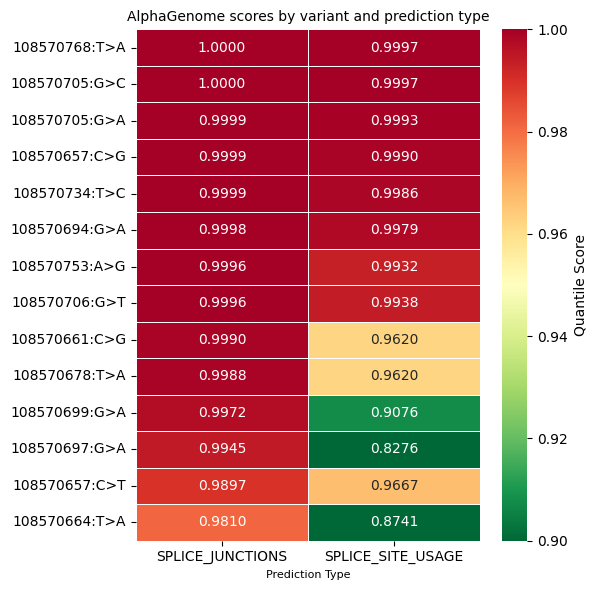

In [27]:
# Plot 2: Scores heatmap
plot_scores_heatmap(combined_df, summary_df, OUTPUT_DIR)

Saved: variant_genomic_positions.png/svg


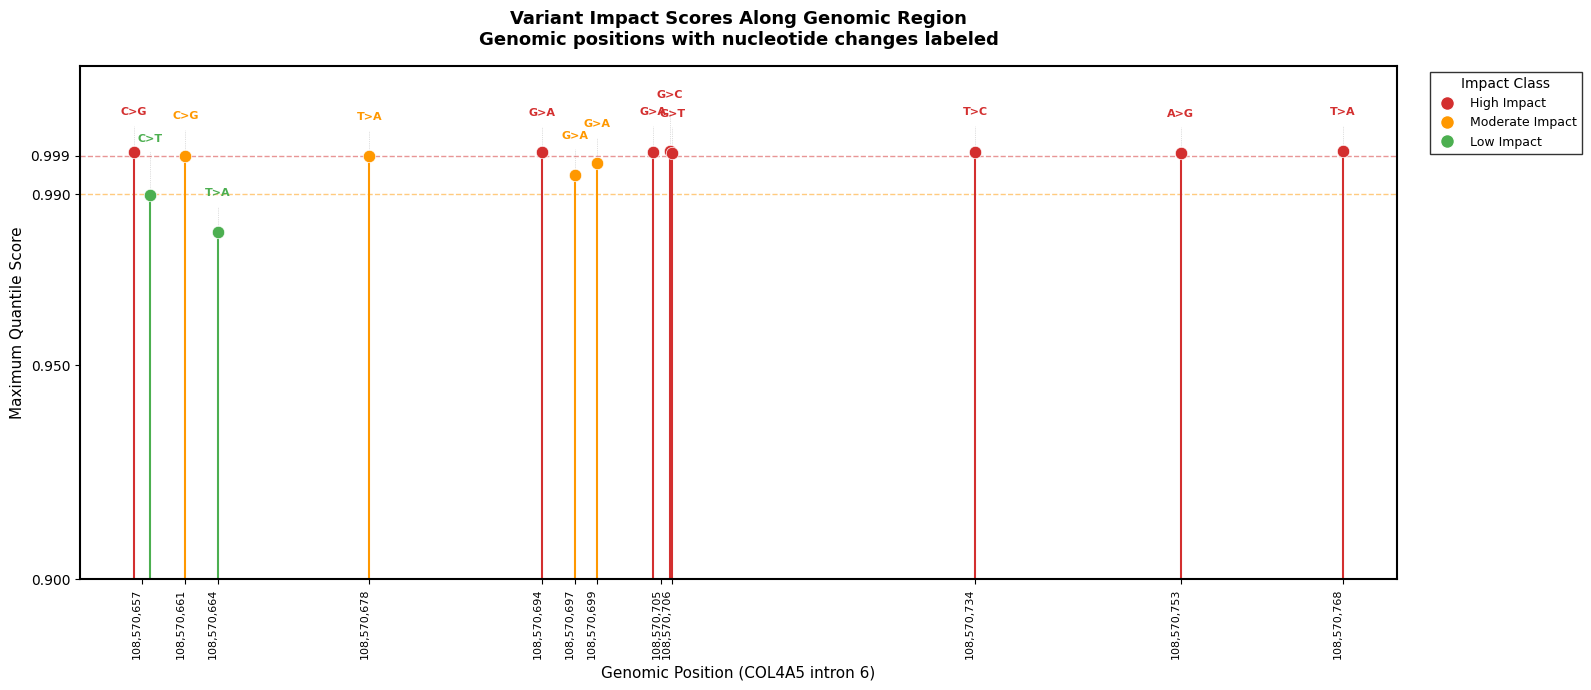

In [28]:
# Plot 3: Genomic positions
from mizani.formatters import comma_format
plot_genomic_positions(summary_df, OUTPUT_DIR)

### 9.4 Save Summary Table

In [29]:
# Save and display summary table
final_summary = save_summary_table(summary_df, OUTPUT_DIR)

print("\nFinal Summary Table:")
display(final_summary)

Saved: variant_pathogenicity_summary.csv

Final Summary Table:


,Variant ID,Position,Change,Impact Classification,Max Quantile Score,Max Raw Score,Mean Quantile Score,Splice Junction Max,Splice Site Max,N Predictions
13,chrX:108570768:T>A,108570768,T>A,High Impact,0.999974,3.007812,0.999818,0.999974,0.999741,4
1,chrX:108570705:G>C,108570705,G>C,High Impact,0.999960,2.810547,0.999822,0.999960,0.999689,6
0,chrX:108570705:G>A,108570705,G>A,High Impact,0.999927,2.304688,0.999611,0.999927,0.999270,6
10,chrX:108570657:C>G,108570657,C>G,High Impact,0.999920,2.238281,0.996605,0.999920,0.999015,8
3,chrX:108570734:T>C,108570734,T>C,High Impact,0.999900,2.083984,0.999325,0.999900,0.998608,6
5,chrX:108570694:G>A,108570694,G>A,High Impact,0.999759,1.531250,0.998959,0.999759,0.997941,6
6,chrX:108570753:A>G,108570753,A>G,High Impact,0.999634,1.281250,0.996606,0.999634,0.993197,6
7,chrX:108570706:G>T,108570706,G>T,High Impact,0.999617,1.250000,0.997142,0.999617,0.993793,6
9,chrX:108570661:C>G,108570661,C>G,Moderate Impact,0.998992,0.738281,0.959337,0.998992,0.961951,6
8,chrX:108570678:T>A,108570678,T>A,Moderate Impact,0.998842,0.690918,0.965095,0.998842,0.961951,6


---
## 10. Analysis Complete

All outputs have been saved to the output directory:
- `variant_pathogenicity_summary.csv` - Summary table
- `variant_scores_heatmap.png/svg` - Heatmap
- `variant_genomic_positions.png/svg` - Position plot
- `variant_score_distributions.png/svg` - Distribution plots

In [31]:
# ============================================
# Separate chunk: AlphaGenome merged splicing score and ranking
# Formula (recommended):
# max(SPLICE_SITES) + max(SPLICE_SITE_USAGE) + max(SPLICE_JUNCTIONS) / 5
# ============================================

required_outputs = ['SPLICE_SITES', 'SPLICE_SITE_USAGE', 'SPLICE_JUNCTIONS']
available_outputs = set(combined_df['output_type'].unique())
missing_outputs = [o for o in required_outputs if o not in available_outputs]
if missing_outputs:
    print(f"Warning: missing output_type rows in combined_df: {missing_outputs}. Using 0 for missing components.")

# Per variant + output type max quantile
max_q = (
    combined_df.groupby(['variant_id', 'output_type'])['quantile_score']
    .max()
    .unstack(fill_value=np.nan)
    .reset_index()
)

# Ensure expected columns exist so merged score is always computable.
for col in required_outputs:
    if col not in max_q.columns:
        max_q[col] = 0.0

max_q['alphagenome_splicing_merged'] = (
    max_q['SPLICE_SITES'].fillna(0)
    + max_q['SPLICE_SITE_USAGE'].fillna(0)
    + (max_q['SPLICE_JUNCTIONS'].fillna(0) / 5.0)
)

# Merge back to summary_df (safe on re-runs)
summary_df = summary_df.drop(
    columns=['alphagenome_splicing_merged', 'alphagenome_splicing_rank'],
    errors='ignore'
)
summary_df = summary_df.merge(
    max_q[['variant_id', 'alphagenome_splicing_merged']],
    on='variant_id',
    how='left'
)

summary_df['alphagenome_splicing_rank'] = (
    summary_df['alphagenome_splicing_merged']
    .rank(method='min', ascending=False)
    .astype('Int64')
)

summary_df_splicing_ranked = (
    summary_df
    .sort_values('alphagenome_splicing_merged', ascending=False)
    .reset_index(drop=True)
)

summary_df_splicing_ranked[['short_variant', 'alphagenome_splicing_merged', 'alphagenome_splicing_rank']].head(20)

,short_variant,alphagenome_splicing_merged,alphagenome_splicing_rank
0,108570768:T>A,1.199736,1
1,108570705:G>C,1.199681,2
2,108570705:G>A,1.199255,3
3,108570657:C>G,1.198999,4
4,108570734:T>C,1.198588,5
5,108570694:G>A,1.197892,6
6,108570706:G>T,1.193716,7
7,108570753:A>G,1.193124,8
8,108570657:C>T,1.164652,9
9,108570661:C>G,1.161749,10
